# Assignment 2 - Predicting Car Price

## <strong><u>Task -1</strong></u>

In [2]:
%pip install sklearn
%pip install matplotlib
%pip install numpy

You should consider upgrading via the '/Users/daki/Desktop/SEM 2/ML/Assignment/Assignment 2/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Users/daki/Desktop/SEM 2/ML/Assignment/Assignment 2/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Users/daki/Desktop/SEM 2/ML/Assignment/Assignment 2/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [3]:
from sklearn.model_selection import KFold

#Class
class LinearRegression(object):
    
    kfold = KFold(n_splits=5)

    #init
    def __init__(self, regularization, lr=0.001, method='batch', num_epochs=500, bs = 50, cv=kfold, init_method='zero',use_momentum=False, momentum=0.9):
        self.lr         = lr
        self.num_epochs = num_epochs
        self.bs         = bs
        self.method     = method
        self.cv         = cv
        self.init_method = init_method
        self.regularization = regularization
        self.use_momentum = use_momentum
        self.momentum = momentum

        if not 0 < self.momentum < 1:
            raise ValueError("momentum must be between 0 and 1")
        
    # Initialize weights using zeros or Xavier initialization
    def initialize_weights(self, number_of_inputs):

        if self.init_method == 'zero':
            return np.zeros(number_of_inputs)

        elif self.init_method == 'xavier':
            lower = -(1.0 / np.sqrt(number_of_inputs))
            upper = 1.0 / np.sqrt(number_of_inputs)

            return np.random.uniform(
                lower,
                upper,
                size=number_of_inputs
            )

        else:
            raise ValueError("init_method must be either 'zero' or 'xavier'")   
    #mse
    def mse(self, ytrue, ypred):
        #ytrue shape:  (m, )  ==> m = number of samples
        return ((ypred - ytrue) ** 2).sum() / ytrue.shape[0]

    # Calculate the R-squared score
    def r2(self, ytrue, ypred):
        ss_res = np.sum((ytrue - ypred) ** 2)
        ss_tot = np.sum((ytrue - np.mean(ytrue)) ** 2)
        return 1 - (ss_res / ss_tot)
    
    #fit
    def fit(self, X_train, y_train):
        
        #create a list for keeping kfold scores
        self.kfold_scores = list()
        self.kfold_r2_scores = list()
        
        #cross validation
        for fold, (train_idx, val_idx) in enumerate(self.cv.split(X_train)):
            self.val_loss_old = np.inf
            
            X_cross_train = X_train[train_idx]
            y_cross_train = y_train[train_idx]
            X_cross_val   = X_train[val_idx]
            y_cross_val   = y_train[val_idx]
            
            self.theta = self.initialize_weights(X_cross_train.shape[1])
            self.prev_step = np.zeros_like(self.theta)

            # Store the previous update for momentum     
            for epoch in range(self.num_epochs):
                
                #Shuffle the data a little so that order does not impact our model
                perm = np.random.permutation(X_cross_train.shape[0]) #perm = [2 50 67 1 .... ]
                
                X_cross_train = X_cross_train[perm]
                y_cross_train = y_cross_train[perm]
                
                if self.method == 'mini':

                    for batch_idx in range(0, X_cross_train.shape[0], self.bs):
                        X_batch = X_cross_train[
                            batch_idx:batch_idx + self.bs
                        ]
                        y_batch = y_cross_train[
                            batch_idx:batch_idx + self.bs
                        ]

                        train_loss = self._train(X_batch, y_batch)

                elif self.method == 'sto':

                    # Train using one sample at a time
                    for sample_idx in range(X_cross_train.shape[0]):
                        X_sample = X_cross_train[
                            sample_idx:sample_idx + 1
                        ]
                        y_sample = y_cross_train[
                            sample_idx:sample_idx + 1
                        ]

                        train_loss = self._train(X_sample, y_sample)

                elif self.method == 'batch':

                    # Train using the complete training fold
                    train_loss = self._train(
                        X_cross_train,
                        y_cross_train
                    )

                else:
                    raise ValueError(
                        "method must be 'batch', 'mini', or 'sto'"
    )
                    
                yhat_val = self.predict(X_cross_val)
                val_loss_new = self.mse(y_cross_val, yhat_val)
                
                #early stopping
                if np.allclose(val_loss_new, self.val_loss_old):
                    break
                self.val_loss_old = val_loss_new
                
            # Calculate and save both validation metrics
            val_r2 = self.r2(y_cross_val, yhat_val)

            self.kfold_scores.append(val_loss_new)
            self.kfold_r2_scores.append(val_r2)

            print(
                f"Fold {fold + 1}: "
                f"MSE = {val_loss_new:.4f}, "
                f"R2 = {val_r2:.4f}"
            )
        
    
    #train
    def _train(self, X, y):
        #X shape: (m, n)
        #y shape: (m, )
        #theta shape: (n, )
        
        #1. predict
        yhat = self.predict(X)

        #2. grad
        m = X.shape[0]
        grad = (1/m) * X.T @ (yhat - y) + self.regularization.derivation(self.theta)
        
        # (n, m) @ (m, ) - (m, ) = (m, ) ===> (n, )
                
        #3. update
        step = self.lr * grad

        if self.use_momentum:
            self.theta = self.theta - step + self.momentum * self.prev_step
        else:
            self.theta = self.theta - step

        self.prev_step = step
                
        #return
        return self.mse(y, yhat)
    
    
    #predict
    def predict(self, X):
        return X @ self.theta  #(m, n) @ (n, ) = (m, )  <===== y
    
    #get theta
    def _coef(self):
        return self.theta[1:]
    
    #get bias
    def _bias(self):
        return self.theta[0]
    # Plot feature importance using model coefficients
    def plot_feature_importance(self, feature_names):

            coefficients = self._coef()

            if len(feature_names) != len(coefficients):
                raise ValueError(
                    "Number of feature names must match number of coefficients"
                )

            importance = np.abs(coefficients)
            sorted_indices = np.argsort(importance)

            plt.figure(figsize=(10, 6))
            plt.barh(
                np.array(feature_names)[sorted_indices],
                importance[sorted_indices]
            )

            plt.xlabel("Absolute Coefficient Value")
            plt.ylabel("Features")
            plt.title("Feature Importance")
            plt.tight_layout()
            plt.show()

### <strong><u>Task 1.1</strong></u>

In [4]:
#Testing the R2 score function
import numpy as np
y_actual = np.array([3, 5, 7, 9])
y_predicted = np.array([2.5, 5.5, 6.5, 9.5])

test_model = LinearRegression(regularization=None)

print("R2 score:", test_model.r2(y_actual, y_predicted))

R2 score: 0.95


### <strong><u>Task 1.2</strong></u>

In [5]:
zero_model = LinearRegression(
    regularization=None,
    init_method='zero'
)

xavier_model = LinearRegression(
    regularization=None,
    init_method='xavier'
)

print("Zero weights:", zero_model.initialize_weights(4))
print("Xavier weights:", xavier_model.initialize_weights(4))

Zero weights: [0. 0. 0. 0.]
Xavier weights: [-0.1860033   0.18552393 -0.23437103 -0.08427818]


### <strong><u>Task 1.3</strong></u>

In [6]:
momentum_model = LinearRegression(
    regularization=None,
    use_momentum=True,
    momentum=0.9
)

print("Use momentum:", momentum_model.use_momentum)
print("Momentum value:", momentum_model.momentum)

Use momentum: True
Momentum value: 0.9


### <strong><u>Task 1.4</strong></u>

### **Feature Importance**

The `plot_feature_importance()` method was added to the main
`LinearRegression` class. It uses the absolute values of the learned
coefficients to display the relative importance of the scaled input features.
The function will be called after training the best model in Task 2.

In [7]:
import matplotlib.pyplot as plt

In [8]:
%pip install sklearn
%pip install matplotlib
%pip install numpy
%pip install pandas
%pip install seaborn

You should consider upgrading via the '/Users/daki/Desktop/SEM 2/ML/Assignment/Assignment 2/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Users/daki/Desktop/SEM 2/ML/Assignment/Assignment 2/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Users/daki/Desktop/SEM 2/ML/Assignment/Assignment 2/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Users/daki/Desktop/SEM 2/ML/Assignment/Assignment 2/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
You should consider upgrading via the '/Users/daki/Desktop/SEM 2/ML/Assignment/Assignment 2/.venv/bin/python -m pip install --upgrade pip' comma

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

warnings.filterwarnings('ignore')

In [10]:
#Lasso
class Lasso:
    def __init__(self, l):
        self.l = l
        
    def __call__(self, theta): #__call__ allows us to call class as method
        return self.l * np.sum(np.abs(theta))
    
    def derivation(self, theta):
        return self.l * np.sign(theta)

In [11]:
#Ridge
class Ridge:
    def __init__(self, l):
        self.l = l
        
    def __call__(self, theta): #__call__ allows us to call class as method
        return self.l * np.sum(np.square(theta))
    
    def derivation(self, theta):
        return self.l * 2 * theta

In [12]:
# No penalty for Normal Linear Regression
class NoRegularization:

    def __call__(self, theta):
        return 0

    def derivation(self, theta):
        return np.zeros_like(theta)

In [13]:
#Elastic
class Elastic:
    def __init__(self, l, l_ratio):
        self.l = l
        self.l_ratio = l_ratio
        
    def __call__(self, theta): #__call__ allows us to call class as method
        l1 = self.l_ratio * self.l * np.sum(np.abs(theta))
        l2 = (1 - self.l_ratio) * self.l * np.sum(np.square(theta)) 
        return (l1 + l2)
    
    def derivation(self, theta):
        l1 = self.l * self.l_ratio * np.sign(theta)
        l2 = 2 * self.l * (1 - self.l_ratio) * theta
        return (l1 + l2)

In [14]:
# Normal Linear Regression without regularization
class NormalRegression(LinearRegression):

    def __init__(
        self,
        lr=0.001,
        method='batch',
        num_epochs=500,
        bs=50,
        init_method='zero',
        use_momentum=False,
        momentum=0.9
    ):

        super().__init__(
            regularization=NoRegularization(),
            lr=lr,
            method=method,
            num_epochs=num_epochs,
            bs=bs,
            init_method=init_method,
            use_momentum=use_momentum,
            momentum=momentum
        )

In [15]:
#Lasso
class LassoRegression(LinearRegression):

    def __init__(
        self,
        lr=0.001,
        method='batch',
        l=0.01,
        num_epochs=500,
        bs=50,
        init_method='zero',
        use_momentum=False,
        momentum=0.9
    ):

        super().__init__(
            regularization=Lasso(l),
            lr=lr,
            method=method,
            num_epochs=num_epochs,
            bs=bs,
            init_method=init_method,
            use_momentum=use_momentum,
            momentum=momentum
        )

In [16]:
#Ridge
class RidgeRegression(LinearRegression):

    def __init__(
        self,
        lr=0.001,
        method='batch',
        l=0.01,
        num_epochs=500,
        bs=50,
        init_method='zero',
        use_momentum=False,
        momentum=0.9
    ):

        super().__init__(
            regularization=Ridge(l),
            lr=lr,
            method=method,
            num_epochs=num_epochs,
            bs=bs,
            init_method=init_method,
            use_momentum=use_momentum,
            momentum=momentum
        )

In [17]:
class ElasticRegression(LinearRegression):
    def __init__(self, method, lr, l, l_ratio=0.5):
        self.regularization = Elastic(l, l_ratio)
        super().__init__(self.regularization, lr, method)

### <strong><u>Task 1 Completion Summary</strong></u>

In Task 1, the `LinearRegression` class was modified to include the following improvements:

1. An `r2()` function was added to calculate the R² score.
2. Weight initialization was improved by allowing users to choose between zero and Xavier initialization.
3. Optional momentum was added to gradient descent, including a configurable momentum value between 0 and 1.
4. A `plot_feature_importance()` function was added to visualize feature importance using the absolute values of the model coefficients.

The feature-importance graph will be generated in Task 2 after the best model has been trained using scaled input features.


## **Task 2: Experiments**

### **Data Preparation**

The car-price dataset is loaded to begin the data cleaning and preprocessing process.

In [18]:
df = pd.read_csv('Cars.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [19]:
df['owner'].unique()

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner', 'Test Drive Car'], dtype=object)

### **Cleaning the Owner Feature**

The owner categories are converted into numerical values. Test Drive Cars are removed because they are not ordinary used cars and could distort the model.

In [20]:
owner_map = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5
}

df['owner'] = df['owner'].map(owner_map)

# Remove Test Drive Cars
df = df[df['owner'] != 5]

In [21]:
print(df['owner'].unique())
print("Dataset shape:", df.shape)

[1 2 3 4]
Dataset shape: (8123, 13)


### **Removing CNG and LPG Fuel Types**

CNG and LPG cars are removed because their mileage is measured in `km/kg`, whereas Petrol and Diesel mileage is measured in `kmpl`. Keeping different measurement units could create inconsistent data.

In [22]:
# Remove cars that use CNG or LPG
df = df[~df['fuel'].isin(['CNG', 'LPG'])]

In [23]:
print("Remaining fuel types:", df['fuel'].unique())
print("Dataset shape:", df.shape)

Remaining fuel types: ['Diesel' 'Petrol']
Dataset shape: (8028, 13)


### **Cleaning Numerical Features**

The measurement units are removed from the mileage, engine, and maximum-power columns. The remaining values are converted into numerical format so they can be used by the model.

In [24]:
# Remove units and convert mileage to numbers
df['mileage'] = df['mileage'].str.split().str[0]
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

# Remove units and convert engine capacity to numbers
df['engine'] = df['engine'].str.split().str[0]
df['engine'] = pd.to_numeric(df['engine'], errors='coerce')

# Remove units and convert maximum power to numbers
df['max_power'] = df['max_power'].str.split().str[0]
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')

In [25]:
df[['mileage', 'engine', 'max_power']].dtypes

mileage      float64
engine       float64
max_power    float64
dtype: object

### **Creating the Brand Feature**

The first word of each car name is extracted and used as the car brand. The original name and torque columns are then removed because they will not be used by the prediction model.

In [26]:
# Extract the first word of the car name as its brand
df['brand'] = df['name'].str.split().str[0]

# Remove unused columns
df.drop(columns=['name', 'torque'], inplace=True)

# Reset the row index after removing records
df.reset_index(drop=True, inplace=True)

In [27]:
print(df.columns)
print("Dataset shape:", df.shape)
df.head()

Index(['year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats',
       'brand'],
      dtype='object')
Dataset shape: (8028, 12)


,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0,Maruti
1,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0,Skoda
2,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0,Honda
3,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0,Hyundai
4,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0,Maruti


### **Encoding Categorical Features**

The categorical features are converted into numerical values using Label Encoding so they can be processed by the regression models.

In [28]:
# Create separate encoders for each categorical feature
label_encoder_brand = LabelEncoder()
label_encoder_fuel = LabelEncoder()
label_encoder_seller_type = LabelEncoder()
label_encoder_transmission = LabelEncoder()

# Convert categorical values into numbers
df['brand'] = label_encoder_brand.fit_transform(df['brand'])
df['fuel'] = label_encoder_fuel.fit_transform(df['fuel'])
df['seller_type'] = label_encoder_seller_type.fit_transform(
    df['seller_type']
)
df['transmission'] = label_encoder_transmission.fit_transform(
    df['transmission']
)

# Save the original brand names for the web application
original_brands = label_encoder_brand.classes_.tolist()

In [29]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,2014,450000,145500,0,1,1,1,23.40,1248.0,74.00,5.0,20
1,2014,370000,120000,0,1,1,2,21.14,1498.0,103.52,5.0,27
2,2006,158000,140000,1,1,1,3,17.70,1497.0,78.00,5.0,10
3,2010,225000,127000,0,1,1,1,23.00,1396.0,90.00,5.0,11
4,2007,130000,120000,1,1,1,1,16.10,1298.0,88.20,5.0,20


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8028 entries, 0 to 8027
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           8028 non-null   int64  
 1   selling_price  8028 non-null   int64  
 2   km_driven      8028 non-null   int64  
 3   fuel           8028 non-null   int64  
 4   seller_type    8028 non-null   int64  
 5   transmission   8028 non-null   int64  
 6   owner          8028 non-null   int64  
 7   mileage        7814 non-null   float64
 8   engine         7814 non-null   float64
 9   max_power      7820 non-null   float64
 10  seats          7814 non-null   float64
 11  brand          8028 non-null   int64  
dtypes: float64(4), int64(8)
memory usage: 752.8 KB


### **Feature Selection**

The features `max_power`, `mileage`, `year`, and `brand` are selected because they provide useful information for estimating a car's selling price. The target is transformed using the natural logarithm to reduce its right-skewed distribution.

In [31]:
# Select the input features
X = df[['max_power', 'mileage', 'year', 'brand']].copy()

# Apply a log transformation to the target
y = np.log(df['selling_price'])

In [32]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (8028, 4)
y shape: (8028,)


,max_power,mileage,year,brand
0,74.00,23.40,2014,20
1,103.52,21.14,2014,27
2,78.00,17.70,2006,10
3,90.00,23.00,2010,11
4,88.20,16.10,2007,20


### **Train-Test Split**

The dataset is divided into training and testing sets. The training set contains 70% of the data, while the remaining 30% is reserved for the final evaluation on unseen data.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [34]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5619, 4)
X_test shape: (2409, 4)
y_train shape: (5619,)
y_test shape: (2409,)


### **Checking Missing Values**

The training and testing datasets are checked for missing values before model training.

In [35]:
print("Missing values in X_train:")
print(X_train.isnull().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum())

print("\nMissing values in y_train:", y_train.isnull().sum())
print("Missing values in y_test:", y_test.isnull().sum())

Missing values in X_train:
max_power    149
mileage      154
year           0
brand          0
dtype: int64

Missing values in X_test:
max_power    59
mileage      60
year          0
brand         0
dtype: int64

Missing values in y_train: 0
Missing values in y_test: 0


### **Handling Missing Values**

Missing `max_power` values are replaced with the training-set median because maximum power can contain extreme values. Missing `mileage` values are replaced with the training-set mean. The same training-set values are applied to the test data to prevent data leakage.

In [36]:
# Calculate replacement values using only the training data
max_power_median = X_train['max_power'].median()
mileage_mean = X_train['mileage'].mean()

# Fill missing training values
X_train['max_power'] = X_train['max_power'].fillna(max_power_median)
X_train['mileage'] = X_train['mileage'].fillna(mileage_mean)

# Apply the same values to the test data
X_test['max_power'] = X_test['max_power'].fillna(max_power_median)
X_test['mileage'] = X_test['mileage'].fillna(mileage_mean)

In [37]:
print("Training missing values:", X_train.isnull().sum().sum())
print("Testing missing values:", X_test.isnull().sum().sum())

Training missing values: 0
Testing missing values: 0


### **Feature Scaling**

Min-Max scaling is fitted on the training data and then applied to both the training and testing data. This places the input features within a similar range and prevents information from the test set from influencing preprocessing.

In [38]:
# Store the feature names before converting to NumPy arrays
feature_names = X_train.columns.tolist()

# Create and fit the scaler using only the training data
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

print("Training minimum:", X_train_scaled.min())
print("Training maximum:", X_train_scaled.max())

Training shape: (5619, 4)
Testing shape: (2409, 4)
Training minimum: 0.0
Training maximum: 1.0


### **Adding the Bias Column**

A column of ones is added as the first input column. Its coefficient acts as the intercept or bias of the regression model.

In [40]:
# Add a column of ones for the bias term
X_train_model = np.hstack([
    np.ones((X_train_scaled.shape[0], 1)),
    X_train_scaled
])

X_test_model = np.hstack([
    np.ones((X_test_scaled.shape[0], 1)),
    X_test_scaled
])

# Convert target Series into NumPy arrays
y_train_model = y_train.to_numpy()
y_test_model = y_test.to_numpy()

In [41]:
print("X_train_model shape:", X_train_model.shape)
print("X_test_model shape:", X_test_model.shape)
print("Feature names:", feature_names)

X_train_model shape: (5619, 5)
X_test_model shape: (2409, 5)
Feature names: ['max_power', 'mileage', 'year', 'brand']


## **MLflow Experiment Tracking**

MLflow is used to record the configuration, cross-validation MSE, and cross-validation R² of every model experiment.

In [42]:
%pip install mlflow

You should consider upgrading via the '/Users/daki/Desktop/SEM 2/ML/Assignment/Assignment 2/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [43]:
import mlflow

mlflow.set_experiment(
    "A2-Car-Price-Experiments"
)

print("MLflow experiment is ready.")

MLflow experiment is ready.


### **Baseline Model**

A normal linear regression model is trained using batch gradient descent, zero initialization, no momentum, and a learning rate of 0.01. Five-fold cross-validation is used to calculate the average MSE and R².

In [44]:
np.random.seed(42)

baseline_model = NormalRegression(
    lr=0.01,
    method='batch',
    num_epochs=500,
    init_method='zero',
    use_momentum=False
)

with mlflow.start_run(run_name='baseline_normal'):

    baseline_model.fit(
        X_train_model,
        y_train_model
    )

    baseline_mse = np.mean(
        baseline_model.kfold_scores
    )

    baseline_r2 = np.mean(
        baseline_model.kfold_r2_scores
    )

    mlflow.log_params({
        'model': 'normal',
        'learning_rate': 0.01,
        'method': 'batch',
        'initialization': 'zero',
        'use_momentum': False,
        'polynomial_degree': 1
    })

    mlflow.log_metrics({
        'cv_mse': baseline_mse,
        'cv_r2': baseline_r2
    })

Fold 1: MSE = 0.6934, R2 = -0.0087
Fold 2: MSE = 0.7360, R2 = -0.0448
Fold 3: MSE = 0.7239, R2 = -0.0085
Fold 4: MSE = 0.7473, R2 = -0.0342
Fold 5: MSE = 0.7348, R2 = -0.0912


In [45]:
def create_polynomial_features(
    X_scaled,
    feature_names,
    degree=2
):
    # Begin with the bias and original features
    features = [
        np.ones((X_scaled.shape[0], 1)),
        X_scaled
    ]

    polynomial_names = list(feature_names)

    # Add squared and higher-degree features
    for current_degree in range(2, degree + 1):
        features.append(X_scaled ** current_degree)

        polynomial_names.extend([
            f"{name}^{current_degree}"
            for name in feature_names
        ])

    return np.hstack(features), polynomial_names

In [46]:
X_train_poly, polynomial_feature_names = (
    create_polynomial_features(
        X_train_scaled,
        feature_names,
        degree=2
    )
)

X_test_poly, _ = create_polynomial_features(
    X_test_scaled,
    feature_names,
    degree=2
)

In [47]:
print("Polynomial training shape:", X_train_poly.shape)
print("Polynomial testing shape:", X_test_poly.shape)
print("Polynomial features:", polynomial_feature_names)

Polynomial training shape: (5619, 9)
Polynomial testing shape: (2409, 9)
Polynomial features: ['max_power', 'mileage', 'year', 'brand', 'max_power^2', 'mileage^2', 'year^2', 'brand^2']


In [48]:
def run_cv_experiment(
    run_name,
    model,
    X_data,
    y_data,
    model_name,
    learning_rate,
    method,
    initialization,
    use_momentum,
    polynomial_degree=1,
    regularization_strength=0
):
    np.random.seed(42)

    with mlflow.start_run(run_name=run_name):

        model.fit(X_data, y_data)

        average_mse = float(
            np.mean(model.kfold_scores)
        )

        average_r2 = float(
            np.mean(model.kfold_r2_scores)
        )

        mlflow.log_params({
            'model': model_name,
            'learning_rate': learning_rate,
            'method': method,
            'initialization': initialization,
            'use_momentum': use_momentum,
            'momentum_value': model.momentum,
            'polynomial_degree': polynomial_degree,
            'regularization_strength':
                regularization_strength
        })

        mlflow.log_metrics({
            'cv_mse': average_mse,
            'cv_r2': average_r2
        })

    return {
        'Model': model_name,
        'Learning Rate': learning_rate,
        'Method': method,
        'Initialization': initialization,
        'Momentum': use_momentum,
        'Polynomial Degree': polynomial_degree,
        'Regularization Strength':
            regularization_strength,
        'Average CV MSE': average_mse,
        'Average CV R2': average_r2
    }

In [49]:
model_results = []

# 1. Normal Linear Regression
normal_model = NormalRegression(
    lr=0.01,
    method='mini',
    num_epochs=500,
    bs=50,
    init_method='xavier',
    use_momentum=True,
    momentum=0.5
)

model_results.append(
    run_cv_experiment(
        run_name='model_normal',
        model=normal_model,
        X_data=X_train_model,
        y_data=y_train_model,
        model_name='Normal',
        learning_rate=0.01,
        method='mini',
        initialization='xavier',
        use_momentum=True,
        polynomial_degree=1
    )
)
# 2. Polynomial Regression
polynomial_model = NormalRegression(
    lr=0.01,
    method='mini',
    num_epochs=500,
    bs=50,
    init_method='xavier',
    use_momentum=True,
    momentum=0.5
)

model_results.append(
    run_cv_experiment(
        run_name='model_polynomial',
        model=polynomial_model,
        X_data=X_train_poly,
        y_data=y_train_model,
        model_name='Polynomial',
        learning_rate=0.01,
        method='mini',
        initialization='xavier',
        use_momentum=True,
        polynomial_degree=2
    )
)
# 3. Lasso Regression
lasso_model = LassoRegression(
    lr=0.01,
    method='mini',
    l=0.01,
    num_epochs=500,
    bs=50,
    init_method='xavier',
    use_momentum=True,
    momentum=0.5
)

model_results.append(
    run_cv_experiment(
        run_name='model_lasso',
        model=lasso_model,
        X_data=X_train_model,
        y_data=y_train_model,
        model_name='Lasso',
        learning_rate=0.01,
        method='mini',
        initialization='xavier',
        use_momentum=True,
        polynomial_degree=1,
        regularization_strength=0.01
    )
)
# 4. Ridge Regression
ridge_model = RidgeRegression(
    lr=0.01,
    method='mini',
    l=0.01,
    num_epochs=500,
    bs=50,
    init_method='xavier',
    use_momentum=True,
    momentum=0.5
)

model_results.append(
    run_cv_experiment(
        run_name='model_ridge',
        model=ridge_model,
        X_data=X_train_model,
        y_data=y_train_model,
        model_name='Ridge',
        learning_rate=0.01,
        method='mini',
        initialization='xavier',
        use_momentum=True,
        polynomial_degree=1,
        regularization_strength=0.01
    )
)

Fold 1: MSE = 0.1304, R2 = 0.8103
Fold 2: MSE = 0.1263, R2 = 0.8207
Fold 3: MSE = 0.1291, R2 = 0.8202
Fold 4: MSE = 0.1177, R2 = 0.8371
Fold 5: MSE = 0.1153, R2 = 0.8288
Fold 1: MSE = 0.1230, R2 = 0.8210
Fold 2: MSE = 0.1280, R2 = 0.8183
Fold 3: MSE = 0.1282, R2 = 0.8214
Fold 4: MSE = 0.1143, R2 = 0.8418
Fold 5: MSE = 0.1180, R2 = 0.8247
Fold 1: MSE = 0.1225, R2 = 0.8218
Fold 2: MSE = 0.1305, R2 = 0.8147
Fold 3: MSE = 0.1245, R2 = 0.8266
Fold 4: MSE = 0.1100, R2 = 0.8477
Fold 5: MSE = 0.1174, R2 = 0.8256
Fold 1: MSE = 0.2761, R2 = 0.5983
Fold 2: MSE = 0.2853, R2 = 0.5950
Fold 3: MSE = 0.2865, R2 = 0.6009
Fold 4: MSE = 0.2749, R2 = 0.6195
Fold 5: MSE = 0.2844, R2 = 0.5776


In [50]:
model_results_df = pd.DataFrame(model_results)

model_results_df.sort_values(
    by='Average CV MSE'
).reset_index(drop=True)

,Model,Learning Rate,Method,Initialization,Momentum,Polynomial Degree,Regularization Strength,Average CV MSE,Average CV R2
0,Lasso,0.01,mini,xavier,True,1,0.01,0.120989,0.827296
1,Polynomial,0.01,mini,xavier,True,2,0.00,0.122312,0.825457
2,Normal,0.01,mini,xavier,True,1,0.00,0.123735,0.823449
3,Ridge,0.01,mini,xavier,True,1,0.01,0.281465,0.598259


### **Learning Rate Comparison**

The learning rates 0.01, 0.001, and 0.0001 are compared using the best-performing regression model from the initial model comparison.

In [51]:
learning_rate_results = []

for current_lr in [0.01, 0.001, 0.0001]:

    current_model = LassoRegression(
        lr=current_lr,
        method='mini',
        l=0.01,
        num_epochs=500,
        bs=50,
        init_method='xavier',
        use_momentum=True,
        momentum=0.5
    )

    result = run_cv_experiment(
        run_name=f'learning_rate_{current_lr}',
        model=current_model,
        X_data=X_train_model,
        y_data=y_train_model,
        model_name='Lasso',
        learning_rate=current_lr,
        method='mini',
        initialization='xavier',
        use_momentum=True,
        polynomial_degree=1,
        regularization_strength=0.01
    )

    learning_rate_results.append(result)

Fold 1: MSE = 0.1225, R2 = 0.8218
Fold 2: MSE = 0.1305, R2 = 0.8147
Fold 3: MSE = 0.1245, R2 = 0.8266
Fold 4: MSE = 0.1100, R2 = 0.8477
Fold 5: MSE = 0.1174, R2 = 0.8256
Fold 1: MSE = 0.3224, R2 = 0.5310
Fold 2: MSE = 0.3671, R2 = 0.4790
Fold 3: MSE = 0.3489, R2 = 0.5139
Fold 4: MSE = 0.3577, R2 = 0.5049
Fold 5: MSE = 0.3617, R2 = 0.4628
Fold 1: MSE = 0.7274, R2 = -0.0582
Fold 2: MSE = 0.8393, R2 = -0.1913
Fold 3: MSE = 0.8723, R2 = -0.2151
Fold 4: MSE = 0.8386, R2 = -0.1606
Fold 5: MSE = 0.8963, R2 = -0.3310


In [52]:
learning_rate_results_df = pd.DataFrame(
    learning_rate_results
)

learning_rate_results_df[
    [
        'Learning Rate',
        'Average CV MSE',
        'Average CV R2'
    ]
].sort_values(
    by='Average CV MSE'
).reset_index(drop=True)

,Learning Rate,Average CV MSE,Average CV R2
0,0.0100,0.120989,0.827296
1,0.0010,0.351575,0.498317
2,0.0001,0.834774,-0.191254


### **Gradient Descent Method Comparison**

Batch, mini-batch, and stochastic gradient descent are compared using the best model and learning rate identified in the previous experiments.

In [53]:
method_results = []

for current_method in ['batch', 'mini', 'sto']:

    current_model = LassoRegression(
        lr=0.01,
        method=current_method,
        l=0.01,
        num_epochs=500,
        bs=50,
        init_method='xavier',
        use_momentum=True,
        momentum=0.5
    )

    result = run_cv_experiment(
        run_name=f'method_{current_method}',
        model=current_model,
        X_data=X_train_model,
        y_data=y_train_model,
        model_name='Lasso',
        learning_rate=0.01,
        method=current_method,
        initialization='xavier',
        use_momentum=True,
        polynomial_degree=1,
        regularization_strength=0.01
    )

    method_results.append(result)

Fold 1: MSE = 0.7150, R2 = -0.0400
Fold 2: MSE = 0.8277, R2 = -0.1749
Fold 3: MSE = 0.8576, R2 = -0.1947
Fold 4: MSE = 0.8269, R2 = -0.1445
Fold 5: MSE = 0.8825, R2 = -0.3106
Fold 1: MSE = 0.1225, R2 = 0.8218
Fold 2: MSE = 0.1305, R2 = 0.8147
Fold 3: MSE = 0.1245, R2 = 0.8266
Fold 4: MSE = 0.1100, R2 = 0.8477
Fold 5: MSE = 0.1174, R2 = 0.8256
Fold 1: MSE = 0.1231, R2 = 0.8210
Fold 2: MSE = 0.1319, R2 = 0.8127
Fold 3: MSE = 0.1251, R2 = 0.8257
Fold 4: MSE = 0.1139, R2 = 0.8424
Fold 5: MSE = 0.1147, R2 = 0.8296


In [54]:
method_results_df = pd.DataFrame(method_results)

method_results_df[
    [
        'Method',
        'Average CV MSE',
        'Average CV R2'
    ]
].sort_values(
    by='Average CV MSE'
).reset_index(drop=True)

,Method,Average CV MSE,Average CV R2
0,mini,0.120989,0.827296
1,sto,0.121733,0.826301
2,batch,0.821938,-0.172927


### **Weight Initialization Comparison**

Zero and Xavier weight initialization are compared using Lasso Regression, a learning rate of 0.01, and mini-batch gradient descent.

In [55]:
initialization_results = []

for current_initialization in ['zero', 'xavier']:

    current_model = LassoRegression(
        lr=0.01,
        method='mini',
        l=0.01,
        num_epochs=500,
        bs=50,
        init_method=current_initialization,
        use_momentum=True,
        momentum=0.5
    )

    result = run_cv_experiment(
        run_name=f'initialization_{current_initialization}',
        model=current_model,
        X_data=X_train_model,
        y_data=y_train_model,
        model_name='Lasso',
        learning_rate=0.01,
        method='mini',
        initialization=current_initialization,
        use_momentum=True,
        polynomial_degree=1,
        regularization_strength=0.01
    )

    initialization_results.append(result)

Fold 1: MSE = 0.1289, R2 = 0.8125
Fold 2: MSE = 0.1303, R2 = 0.8151
Fold 3: MSE = 0.1318, R2 = 0.8164
Fold 4: MSE = 0.1099, R2 = 0.8478
Fold 5: MSE = 0.1143, R2 = 0.8303
Fold 1: MSE = 0.1225, R2 = 0.8218
Fold 2: MSE = 0.1305, R2 = 0.8147
Fold 3: MSE = 0.1245, R2 = 0.8266
Fold 4: MSE = 0.1100, R2 = 0.8477
Fold 5: MSE = 0.1174, R2 = 0.8256


In [56]:
initialization_results_df = pd.DataFrame(
    initialization_results
)

initialization_results_df[
    [
        'Initialization',
        'Average CV MSE',
        'Average CV R2'
    ]
].sort_values(
    by='Average CV MSE'
).reset_index(drop=True)

,Initialization,Average CV MSE,Average CV R2
0,xavier,0.120989,0.827296
1,zero,0.123028,0.824437


### **Momentum Comparison**

The model is trained with and without momentum to determine whether momentum improves convergence and cross-validation performance.

In [57]:
momentum_results = []

for current_momentum_setting in [True, False]:

    current_model = LassoRegression(
        lr=0.01,
        method='mini',
        l=0.01,
        num_epochs=500,
        bs=50,
        init_method='xavier',
        use_momentum=current_momentum_setting,
        momentum=0.5
    )

    result = run_cv_experiment(
        run_name=(
            f'momentum_{current_momentum_setting}'
        ),
        model=current_model,
        X_data=X_train_model,
        y_data=y_train_model,
        model_name='Lasso',
        learning_rate=0.01,
        method='mini',
        initialization='xavier',
        use_momentum=current_momentum_setting,
        polynomial_degree=1,
        regularization_strength=0.01
    )

    momentum_results.append(result)

Fold 1: MSE = 0.1225, R2 = 0.8218
Fold 2: MSE = 0.1305, R2 = 0.8147
Fold 3: MSE = 0.1245, R2 = 0.8266
Fold 4: MSE = 0.1100, R2 = 0.8477
Fold 5: MSE = 0.1174, R2 = 0.8256
Fold 1: MSE = 0.1225, R2 = 0.8218
Fold 2: MSE = 0.1289, R2 = 0.8170
Fold 3: MSE = 0.1251, R2 = 0.8258
Fold 4: MSE = 0.1096, R2 = 0.8482
Fold 5: MSE = 0.1138, R2 = 0.8310


In [58]:
momentum_results_df = pd.DataFrame(
    momentum_results
)

momentum_results_df[
    [
        'Momentum',
        'Average CV MSE',
        'Average CV R2'
    ]
].sort_values(
    by='Average CV MSE'
).reset_index(drop=True)

,Momentum,Average CV MSE,Average CV R2
0,False,0.119983,0.828772
1,True,0.120989,0.827296


In [59]:
#final model training using the best hyperparameters
def fit_final_model(model, X_data, y_data):

    np.random.seed(42)

    # Initialize weights
    model.theta = model.initialize_weights(
        X_data.shape[1]
    )

    model.prev_step = np.zeros_like(model.theta)

    # Train using all training samples
    for epoch in range(model.num_epochs):

        permutation = np.random.permutation(
            X_data.shape[0]
        )

        X_shuffled = X_data[permutation]
        y_shuffled = y_data[permutation]

        if model.method == 'mini':

            for batch_idx in range(
                0,
                X_shuffled.shape[0],
                model.bs
            ):
                X_batch = X_shuffled[
                    batch_idx:batch_idx + model.bs
                ]

                y_batch = y_shuffled[
                    batch_idx:batch_idx + model.bs
                ]

                model._train(X_batch, y_batch)

        elif model.method == 'sto':

            for sample_idx in range(
                X_shuffled.shape[0]
            ):
                model._train(
                    X_shuffled[
                        sample_idx:sample_idx + 1
                    ],
                    y_shuffled[
                        sample_idx:sample_idx + 1
                    ]
                )

        elif model.method == 'batch':

            model._train(
                X_shuffled,
                y_shuffled
            )

        else:
            raise ValueError(
                "method must be 'batch', 'mini', or 'sto'"
            )

    return model

## **Final Model Evaluation**

The best configuration identified through cross-validation is retrained using the complete training dataset. It is then evaluated once using the previously untouched test set.

In [60]:
final_model = LassoRegression(
    lr=0.01,
    method='mini',
    l=0.01,
    num_epochs=500,
    bs=50,
    init_method='xavier',
    use_momentum=False,
    momentum=0.5
)

with mlflow.start_run(run_name='final_best_model'):

    final_model = fit_final_model(
        final_model,
        X_train_model,
        y_train_model
    )

    # Predict logarithmic prices
    test_predictions_log = final_model.predict(
        X_test_model
    )

    # Convert predictions and actual values back to price
    test_predictions = np.exp(
        test_predictions_log
    )

    actual_test_prices = np.exp(
        y_test_model
    )

    # Calculate final test metrics
    final_test_mse = final_model.mse(
        actual_test_prices,
        test_predictions
    )

    final_test_r2 = final_model.r2(
        actual_test_prices,
        test_predictions
    )

    mlflow.log_params({
        'model': 'Lasso',
        'learning_rate': 0.01,
        'method': 'mini',
        'initialization': 'xavier',
        'use_momentum': False,
        'polynomial_degree': 1,
        'regularization_strength': 0.01
    })

    mlflow.log_metrics({
        'test_mse': float(final_test_mse),
        'test_r2': float(final_test_r2)
    })

In [61]:
print(
    f"Final Test MSE: {final_test_mse:,.2f}"
)

print(
    f"Final Test R2: {final_test_r2:.4f}"
)

Final Test MSE: 300,399,148,285.80
Final Test R2: 0.5505


In [62]:
final_test_mse_log = final_model.mse(
    y_test_model,
    test_predictions_log
)

final_test_r2_log = final_model.r2(
    y_test_model,
    test_predictions_log
)

print(
    f"Final Test MSE (Log Scale): "
    f"{final_test_mse_log:.4f}"
)

print(
    f"Final Test R2 (Log Scale): "
    f"{final_test_r2_log:.4f}"
)

Final Test MSE (Log Scale): 0.1168
Final Test R2 (Log Scale): 0.8341


In [63]:
last_run = mlflow.last_active_run()

with mlflow.start_run(
    run_id=last_run.info.run_id
):
    mlflow.log_metrics({
        'test_mse_log': float(
            final_test_mse_log
        ),
        'test_r2_log': float(
            final_test_r2_log
        )
    })

### **Feature Importance**

Feature importance is calculated using the absolute values of the final model coefficients. Because the input features were scaled before training, their coefficient magnitudes can be compared more meaningfully.

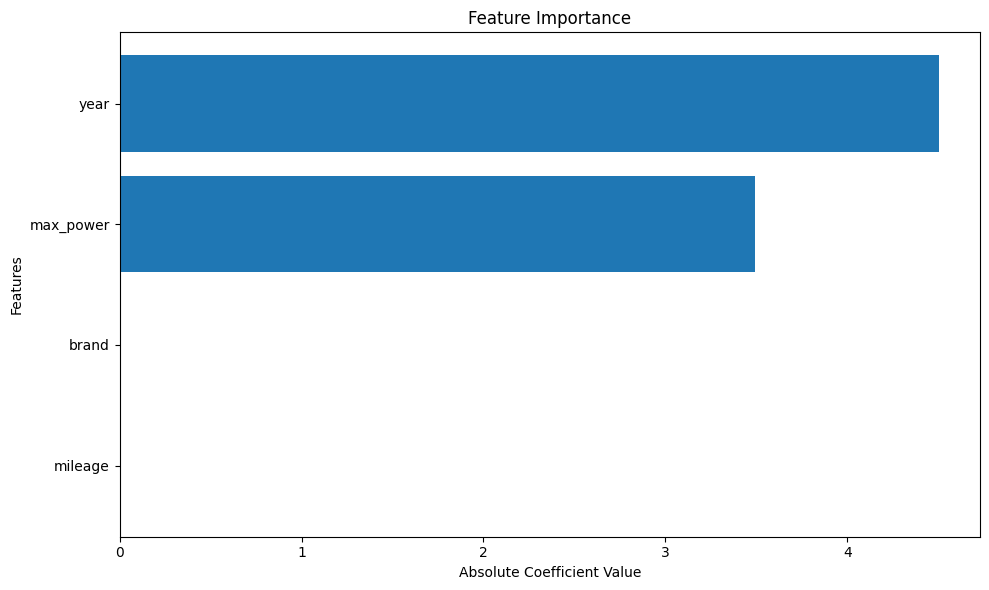

In [64]:
final_model.plot_feature_importance(
    feature_names
)

## **Final Experiment Comparison Table**

The following table combines all model and hyperparameter experiments tracked during cross-validation.

In [65]:
final_comparison_table = pd.concat([
    pd.DataFrame(model_results).assign(
        Experiment='Model Comparison'
    ),
    pd.DataFrame(learning_rate_results).assign(
        Experiment='Learning Rate'
    ),
    pd.DataFrame(method_results).assign(
        Experiment='Training Method'
    ),
    pd.DataFrame(initialization_results).assign(
        Experiment='Initialization'
    ),
    pd.DataFrame(momentum_results).assign(
        Experiment='Momentum'
    )
], ignore_index=True)

In [66]:
final_comparison_table = final_comparison_table[
    [
        'Experiment',
        'Model',
        'Learning Rate',
        'Method',
        'Initialization',
        'Momentum',
        'Polynomial Degree',
        'Regularization Strength',
        'Average CV MSE',
        'Average CV R2'
    ]
]

final_comparison_table

,Experiment,Model,Learning Rate,Method,Initialization,Momentum,Polynomial Degree,Regularization Strength,Average CV MSE,Average CV R2
0,Model Comparison,Normal,0.0100,mini,xavier,True,1,0.00,0.123735,0.823449
1,Model Comparison,Polynomial,0.0100,mini,xavier,True,2,0.00,0.122312,0.825457
2,Model Comparison,Lasso,0.0100,mini,xavier,True,1,0.01,0.120989,0.827296
3,Model Comparison,Ridge,0.0100,mini,xavier,True,1,0.01,0.281465,0.598259
4,Learning Rate,Lasso,0.0100,mini,xavier,True,1,0.01,0.120989,0.827296
5,Learning Rate,Lasso,0.0010,mini,xavier,True,1,0.01,0.351575,0.498317
6,Learning Rate,Lasso,0.0001,mini,xavier,True,1,0.01,0.834774,-0.191254
7,Training Method,Lasso,0.0100,batch,xavier,True,1,0.01,0.821938,-0.172927
8,Training Method,Lasso,0.0100,mini,xavier,True,1,0.01,0.120989,0.827296
9,Training Method,Lasso,0.0100,sto,xavier,True,1,0.01,0.121733,0.826301


## **Findings and Discussion**

The model comparison showed that Lasso Regression achieved the best cross-validation performance, with an average MSE of **0.120989** and an average R² of **0.827296**. Polynomial and Normal Regression produced similar results, while Ridge Regression performed considerably worse with the selected regularization strength.

A learning rate of **0.01** performed better than 0.001 and 0.0001. Mini-batch gradient descent achieved the best result, although stochastic gradient descent produced a very similar performance. Batch gradient descent performed poorly within the selected 500 training epochs. Xavier initialization slightly outperformed zero initialization. The model also performed slightly better without momentum.

Based on these experiments, the final model was Lasso Regression with a learning rate of 0.01, mini-batch gradient descent, Xavier initialization, a regularization strength of 0.01, and no momentum. On the test set, it achieved a log-scale MSE of **0.1168** and an R² of **0.8341**. On the original price scale, the model achieved an R² of **0.5505** and an MSE of approximately **300.40 billion squared price units**.

The feature-importance graph showed that `year` was the most influential feature, followed by `max_power`. The coefficients for `brand` and `mileage` were reduced close to zero by Lasso regularization. This demonstrates Lasso's ability to reduce the influence of less useful features.


## **MLflow Experiment Screenshots**

### **All Experiment Runs**

The following screenshot shows the MLflow runs created during the model and hyperparameter comparisons.

![MLflow Experiment Runs](mlflow_runs.png)

### **Final Best Model**

The following screenshot shows the parameters and test metrics recorded for the selected final model.

![MLflow Best Model](mlflow_best_model.png)

In [68]:
#Saving the model
import pickle

a2_model_data = {
    'theta': final_model.theta,
    'degree': 1,
    'features': feature_names,
    'model_name': 'Lasso'
}

a2_imputation_values = {
    'max_power': float(max_power_median),
    'mileage': float(mileage_mean),
    'year': float(X_train['year'].median()),
    'brand': int(X_train['brand'].mode()[0])
}

In [69]:
with open('a2_model_data.pkl', 'wb') as file:
    pickle.dump(a2_model_data, file)

with open('a2_scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

with open('a2_brand_encoder.pkl', 'wb') as file:
    pickle.dump(label_encoder_brand, file)

with open('a2_imputation_values.pkl', 'wb') as file:
    pickle.dump(a2_imputation_values, file)

print("A2 model files saved successfully.")

A2 model files saved successfully.


### <strong><u>Task 2 Summary</strong></u>

In Task 2, the original Linear Regression model was extended and improved by implementing several additional modelling and optimization techniques. Normal Linear Regression, Polynomial Regression, Ridge Regression, and Lasso Regression were compared using 5-fold cross-validation. The experiments also evaluated different learning rates, gradient descent methods, weight initialization techniques, and momentum settings.

Based on the cross-validation results, Lasso Regression achieved the best overall performance, with an average CV MSE of approximately **0.1210** and an average CV R² score of approximately **0.8273**. The selected configuration used:

- **Model:** Lasso Regression
- **Regularization strength:** 0.01
- **Learning rate:** 0.01
- **Gradient descent method:** Mini-batch
- **Weight initialization:** Xavier initialization
- **Momentum:** False
- **Polynomial degree:** 1

The final selected model was evaluated only once on the unseen test set. It achieved a log-scale MSE of approximately **0.1168** and a log-scale R² score of approximately **0.8341**. After converting the predictions back to the original selling-price scale, the model achieved an R² score of approximately **0.5505**.

The feature-importance results showed that **year** and **maximum power** had the strongest influence on the predicted selling price. Lasso also reduced the coefficients of less influential features, such as mileage and brand, towards zero.

All model configurations, parameters, and evaluation metrics were recorded using MLflow. Finally, the selected Lasso model and its preprocessing objects were saved so they could be used by the Dash web application.

Overall, Task 2 successfully identified and saved an improved regression model through systematic experimentation, cross-validation, model evaluation, and feature interpretation.

# **Task 3: Deployment**

## **Saving the A2 Model**

The selected A2 Lasso Regression model and its preprocessing components are saved using Pickle so they can be loaded by the web application. The saved components include the model coefficients, Min-Max scaler, brand encoder, and missing-value replacement values.

The new files use the `a2_` prefix so that they do not overwrite the original A1 model files. This allows the website to provide predictions using both the original A1 model and the improved A2 model.


## **Improved Web Application**

The original A1 website was updated to support both the old A1 model and the new A2 model. Two navigation tabs allow users to move between the models. Each page accepts the car's brand, year, mileage, and maximum power before displaying its estimated selling price.

### **Original A1 Model**

The following screenshot shows a prediction produced by the original A1 polynomial regression model.

![Original A1 model website](a1_model_website.png)

### **Improved A2 Model**

The following screenshot shows a prediction produced by the new A2 Lasso Regression model. The model configuration was selected using cross-validation and MLflow experiment tracking.

![Improved A2 model website](a2_model_website.png)

Using the same inputs, the two models produce different estimates because they use different regression approaches and learned coefficients.


## <strong><u>Docker Deployment on the AIT ML Server</strong></u>

The completed Dash application was containerized using Docker and deployed on the AIT ML server. The following steps describe the complete deployment process.

### Step 1: Build and Push the Docker Image

The Docker image was built on the local computer for the `linux/amd64` platform because the AIT ML server uses this architecture. The completed image was pushed to Docker Hub under the repository `dakiiii/car-price-a2`.

```bash
docker buildx build \
  --platform linux/amd64 \
  -t dakiiii/car-price-a2:latest \
  --push .
```

### Step 2: Configure SSH Access

The AIT ML server must be accessed through the Bazooka jump server. Therefore, the following configuration was added to the local `~/.ssh/config` file:

```text
Host bazooka
    HostName bazooka.cs.ait.ac.th
    User st126671
    IdentityFile ~/.ssh/ait_deployment
    IdentitiesOnly yes

Host mlserver
    HostName ml.brain.cs.ait.ac.th
    User st126671
    IdentityFile ~/.ssh/ait_deployment
    IdentitiesOnly yes
    ProxyJump bazooka
```

The hostname `ml.brain.cs.ait.ac.th` was used instead of the IP address because the hostname provided a more reliable connection.

### Step 3: Connect to the ML Server

After configuring SSH, the following command was used to connect to the ML server:

```bash
ssh mlserver
```

The connection passed through the Bazooka jump server. After successful authentication, the following ML server prompt appeared:

```text
st126671@ml-brain:~$
```

This confirmed that the connection to the AIT ML server was successful.

### Step 4: Pull the Docker Image

The Docker image was downloaded from Docker Hub onto the ML server using:

```bash
docker pull dakiiii/car-price-a2:latest
```

The successful download produced the following status:

```text
Status: Downloaded newer image for dakiiii/car-price-a2:latest
```

### Step 5: Check the Existing Docker Containers

The existing containers on the server were checked using:

```bash
docker ps
```

This showed that Traefik was already running on the server. Traefik is used to route requests from the public website address to the Dash application.

The application uses internal port `8050` and must be connected to the existing `web` Docker network.

### Step 6: Run the Application Container

The following command was used to create and start the application container:

```bash
docker run -d \
  --name car-price-st126671 \
  --restart unless-stopped \
  --network web \
  --label "traefik.enable=true" \
  --label 'traefik.http.routers.carprice-st126671.rule=Host(`web-st126671.ml.brain.cs.ait.ac.th`)' \
  --label "traefik.http.routers.carprice-st126671.entrypoints=websecure" \
  --label "traefik.http.routers.carprice-st126671.tls=true" \
  --label "traefik.http.routers.carprice-st126671.tls.certresolver=letsencrypt" \
  --label "traefik.http.services.carprice-st126671.loadbalancer.server.port=8050" \
  dakiiii/car-price-a2:latest
```

In this command:

- `--name car-price-st126671` assigns a unique name to the container.
- `--restart unless-stopped` automatically restarts the application after a server restart.
- `--network web` connects the application to the web network.
- The Traefik labels configure the public hostname and HTTPS.
- Port `8050` is the internal port used by the Dash application.
- `dakiiii/car-price-a2:latest` identifies the Docker image stored on Docker Hub.

### Step 7: Verify the Running Container

The following command was used to confirm that the application container was running:

```bash
docker ps --filter name=car-price-st126671
```

The container displayed the status `Up`, confirming that the application was running successfully.

![Running Docker container](docker_container_running.png)

### Step 8: Access and Test the Deployed Application

The deployed application can be accessed using the following URL:

[https://web-st126671.ml.brain.cs.ait.ac.th](https://web-st126671.ml.brain.cs.ait.ac.th)

Both models were tested using the same inputs:

- **Brand:** Ambassador
- **Year:** 2020
- **Mileage:** 14
- **Maximum Power:** 123

### Original A1 Model

The original A1 model predicted a selling price of **1,191,738.30**.

![Deployed original A1 model](deployed_a1_model.png)

### Improved A2 Model

The improved A2 Lasso Regression model predicted a selling price of **1,335,916.66**.

![Deployed improved A2 model](deployed_a2_model.png)

The two models produced different predictions because they used different learned coefficients and regularization approaches. These results confirm that both models were successfully integrated into the Dash application and deployed on the AIT ML server.

## <strong><u>Conclusion</strong></u>

In this assignment, the original A1 Linear Regression model was improved by testing different regression approaches and training configurations. Normal Linear Regression, Polynomial Regression, Ridge Regression, and Lasso Regression were compared using 5-fold cross-validation. Different learning rates, gradient descent methods, weight initialization methods, and momentum settings were also evaluated and recorded using MLflow.

Lasso Regression produced the best cross-validation performance, with an average MSE of approximately **0.1210** and an average R² score of approximately **0.8273**. The selected model used a learning rate of **0.01**, mini-batch gradient descent, Xavier initialization, and no momentum. On the unseen test set, it achieved a log-scale MSE of approximately **0.1168** and an R² score of approximately **0.8341**. After converting predictions back to the original price scale, the final test R² was approximately **0.5505**.

The feature-importance analysis showed that the car's year and maximum power had the strongest influence on the predicted selling price. Finally, both the original A1 model and improved A2 model were integrated into a Dash web application. The application was containerized with Docker and successfully deployed on the AIT ML server. Overall, the assignment demonstrated the complete machine-learning workflow, including data preparation, model development, experimentation, evaluation, interpretation, containerization, and deployment.